In [1]:
#Imports
import os
import shutil
import numpy as np
import cv2
import random
import tensorflow as tf # type: ignore
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization, UpSampling2D, concatenate, Conv2DTranspose,Lambda
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.metrics import classification_report
from keras import backend as K
from keras import layers, Model
from keras.preprocessing.image import ImageDataGenerator

In [2]:
# REQUIREMENT: Do not add code from Tasks 2 or 4
# REQUIREMENT: All dataset prep (crop/pad/patch/directory structure) must be finalize before attempting this task.
patch_size = 256
# now im also defininf the paths for each train an val set of images/masks
train_image_dir = r"D:\YearTwoAI\Block B\2024-25b-fai2-adsai-VictoriaVicheva233182\dataset_256_new\train_images\train"
train_mask_dir = r"D:\YearTwoAI\Block B\2024-25b-fai2-adsai-VictoriaVicheva233182\dataset_256_new\train_masks\train"
val_image_dir = r"D:\YearTwoAI\Block B\2024-25b-fai2-adsai-VictoriaVicheva233182\dataset_256_new\val_images\val"
val_mask_dir = r"D:\YearTwoAI\Block B\2024-25b-fai2-adsai-VictoriaVicheva233182\dataset_256_new\val_masks\val"


In [3]:
def f1(y_true, y_pred):
    def recall_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = TP / (Positives+K.epsilon())
        # tf.print('Recall - TP:', TP,"positives:", Positives, "recall:", recall)
        return recall
    
    def precision_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = TP / (Pred_Positives+K.epsilon())
        # tf.print('Precision - TP:', TP,"pred-positives:", Pred_Positives, "Precision:", precision)
        return precision
    
    precision, recall = precision_m(y_true, y_pred), recall_m(y_true, y_pred)
    f1_score = 2*((precision*recall)/(precision+recall+K.epsilon()))
    # tf.print('F1:', f1_score)
    
    return f1_score

In [4]:
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
        pt_1 = y_true * K.log(y_pred)
        pt_0 = (1 - y_true) * K.log(1 - y_pred)
        return -alpha * K.pow(1 - y_pred, gamma) * pt_1 - (1 - alpha) * K.pow(y_pred, gamma) * pt_0
    return focal_loss_fixed

In [5]:
def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
# Build the model
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s = inputs

    # Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
     
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
     
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
     
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    # Expansive path 
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
     
    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
     
    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
     
    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
     
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
     
    model = Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[f1])
    model.summary()
    
    return model

In [6]:
# Augmented training image generator
train_image_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    
)

train_image_generator = train_image_datagen.flow_from_directory(
    r"D:\YearTwoAI\Block B\2024-25b-fai2-adsai-VictoriaVicheva233182\dataset_256_new\train_images",
    target_size=(patch_size, patch_size),
    batch_size=8,
    class_mode=None,
    color_mode="grayscale",
    seed=42,
)

# Augmented training mask generator (same transformations without rescaling)
train_mask_datagen = ImageDataGenerator(
    horizontal_flip=True,
    
)

train_mask_generator = train_mask_datagen.flow_from_directory(
        r"D:\YearTwoAI\Block B\2024-25b-fai2-adsai-VictoriaVicheva233182\dataset_256_new\train_masks",
    target_size=(patch_size, patch_size),
    batch_size=8,
    class_mode=None,
    color_mode="grayscale",
    seed=42,
)

# Combine the image and mask generators
train_generator = zip(train_image_generator, train_mask_generator)

# Validation (no augmentation)
val_image_datagen = ImageDataGenerator(rescale=1.0 / 255)

val_image_generator = val_image_datagen.flow_from_directory(
    r"D:\YearTwoAI\Block B\2024-25b-fai2-adsai-VictoriaVicheva233182\dataset_256_new\val_images",
    target_size=(patch_size, patch_size),
    batch_size=8,
    class_mode=None,
    color_mode="grayscale",
    seed=42,
)

val_mask_datagen = ImageDataGenerator()

val_mask_generator = val_mask_datagen.flow_from_directory(
    r"D:\YearTwoAI\Block B\2024-25b-fai2-adsai-VictoriaVicheva233182\dataset_256_new\val_masks",
    target_size=(patch_size, patch_size),
    batch_size=8,
    class_mode=None,
    color_mode="grayscale",
    seed=42,
)

val_generator = zip(val_image_generator, val_mask_generator)

Found 5428 images belonging to 1 classes.
Found 5428 images belonging to 1 classes.
Found 910 images belonging to 1 classes.
Found 910 images belonging to 1 classes.


In [7]:
steps_per_epoch = len(train_image_generator)

model = simple_unet_model(patch_size, patch_size, 1)
# EarlyStopping()
cb = EarlyStopping(
    monitor="val_f1",  # Metric to monitor
    patience=20,  # Number of epochs with no improvement to wait before stopping
    restore_best_weights='True',
    mode='max' # Restore model weights with best metric
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_f1',  
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    mode='max'  
)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 16  160         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 dropout (Dropout)              (None, 256, 256, 16  0           ['conv2d[0][0]']                 
                                )                                                             

In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    batch_size=8,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_image_generator.samples // 12,
    callbacks=[cb],
)
print("Training Loss:", history.history['loss'])
print("Validation F1:", history.history['val_f1'])

Epoch 1/30
679/679 [==============================] - 139s 193ms/step - loss: 0.0616 - f1: 0.4020 - val_loss: 0.0316 - val_f1: 0.7392
Epoch 2/30
679/679 [==============================] - 57s 84ms/step - loss: 0.0296 - f1: 0.7465 - val_loss: 0.0263 - val_f1: 0.7850
Epoch 3/30
679/679 [==============================] - 51s 76ms/step - loss: 0.0250 - f1: 0.7766 - val_loss: 0.0224 - val_f1: 0.8065
Epoch 4/30
679/679 [==============================] - 52s 76ms/step - loss: 0.0227 - f1: 0.7963 - val_loss: 0.0212 - val_f1: 0.8211
Epoch 5/30
679/679 [==============================] - 51s 76ms/step - loss: 0.0215 - f1: 0.8075 - val_loss: 0.0213 - val_f1: 0.8189
Epoch 6/30
679/679 [==============================] - 51s 76ms/step - loss: 0.0205 - f1: 0.8170 - val_loss: 0.0201 - val_f1: 0.8307
Epoch 7/30
679/679 [==============================] - 52s 76ms/step - loss: 0.0201 - f1: 0.8182 - val_loss: 0.0189 - val_f1: 0.8341
Epoch 8/30
679/679 [==============================] - 52s 76ms/step - loss

In [9]:
# REQUIREMENT: Save your model, it is a deliverable
# REQUIREMENT: naming convention 'studentname_studentnumber_unet_model_patchsizepx.h5'
example_file_name = f'victoria_233182_unet_RETAKE_2_{patch_size}px.h5'
print(example_file_name)
model.save(example_file_name)

victoria_233182_unet_RETAKE_2_256px.h5


In [10]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
best_val_loss = min(history.history['val_loss'])
best_val_f1 = max(history.history['val_f1'])
print(f"Best validation loss: {best_val_loss}")
print(f"Best validation f1: {best_val_f1}")

Best validation loss: 0.016655312851071358
Best validation f1: 0.8594675660133362


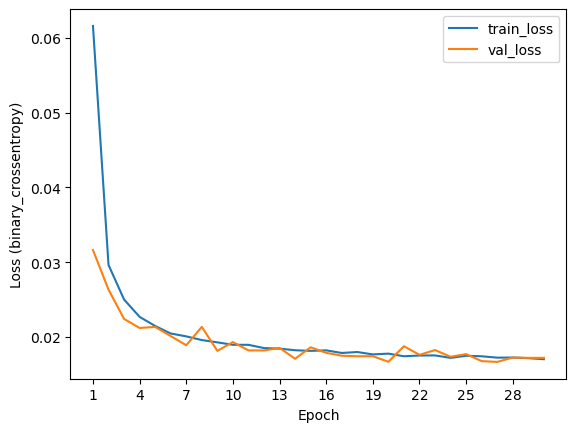

In [11]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = np.arange(1, len(loss) + 1)

plt.plot(epochs, loss, label='train_loss')
plt.plot(epochs, val_loss, label='val_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (binary_crossentropy)')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))

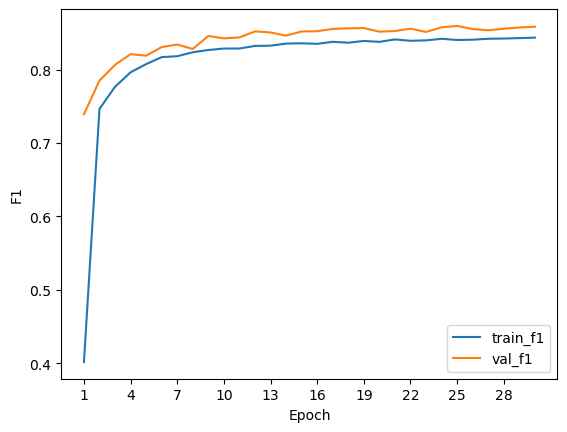

In [12]:
# REQUIREMENT: Run and display the output of this cell.
# REQUIREMENT: Do not change the code.
train_f1 = history.history['f1']
val_f1 = history.history['val_f1']

epochs = np.arange(1, len(train_f1) + 1)

plt.plot(epochs, train_f1, label='train_f1')
plt.plot(epochs, val_f1, label='val_f1')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('F1')
_ = plt.xticks(np.arange(1, len(loss) + 1, 3))